# Embedding Model Comparison - Clustering Evaluation

Questo notebook confronta tre modelli di embedding **tramite metriche di clustering** e valutazione della qualità dei cluster.

A differenza del notebook precedente (diagnosi su norme e chunk), questo notebook si focalizza su:
- Clustering quality (Silhouette, Davies-Bouldin, Calinski-Harabasz)
- Stability (ARI, NMI su boostrap)
- Retrieval metrics (recall@k, MRR)

## Modelli confrontati
- `BAAI/bge-small-en-v1.5` (384 dim, veloce)
- `sentence-transformers/all-MiniLM-L6-v2` (384 dim, ultra-veloce)
- `intfloat/e5-base-v2` (768 dim, alta qualità)

## Setup

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import dotenv_values

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.embedding_comparision import (
    cluster_kmeans,
    compute_clustering_metrics,
    compute_stability_metrics,
    compute_retrieval_metrics,
    reduce_embeddings,
)

ENV_PATH = PROJECT_ROOT / ".env"
ENV = dotenv_values(ENV_PATH)

def project_path(env_key, default):
    value = Path(ENV.get(env_key, default))
    return value if value.is_absolute() else PROJECT_ROOT / value

def get_model_slug(model_name: str) -> str:
    slug = model_name.split('/')[-1]
    slug = slug.replace('.', '-')
    return slug

EMBEDDINGS_ROOT = project_path("DATA_EMBEDDINGS_PATH", "data/embeddings/")
METADATA_ROOT = project_path("METADATA_PATH", "data/metadata/")
FIGURES_ROOT = project_path("FIGURES_PATH", "reports/figures/")
FIGURES_PATH = FIGURES_ROOT / "embedding_model_comparison"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODELS = [
    "BAAI/bge-small-en-v1.5",
    "sentence-transformers/all-MiniLM-L6-v2",
    "intfloat/e5-base-v2",
]

print(f"Modelli: {len(EMBEDDING_MODELS)}")
for model in EMBEDDING_MODELS:
    print(f"  - {get_model_slug(model)}")

Modelli: 3
  - bge-small-en-v1-5
  - all-MiniLM-L6-v2
  - e5-base-v2


## 1. Caricamento embeddings per i 3 modelli

In [2]:
embeddings_data = {}

for model_name in EMBEDDING_MODELS:
    slug = get_model_slug(model_name)
    
    emb_path = EMBEDDINGS_ROOT / f"email_embeddings_{slug}.npy"
    idx_path = METADATA_ROOT / f"email_embedding_index_{slug}.parquet"
    meta_path = METADATA_ROOT / f"email_embedding_metadata_{slug}.json"
    
    if not emb_path.exists():
        print(f"⚠ Mancano embeddings per {slug}")
        continue
    
    embeddings = np.load(emb_path)
    index_df = pd.read_parquet(idx_path)
    with meta_path.open(encoding="utf-8") as f:
        metadata = json.load(f)
    
    embeddings_data[model_name] = {
        "embeddings": embeddings,
        "index": index_df,
        "metadata": metadata,
    }
    
    print(f"✓ {slug:25} | shape: {embeddings.shape}")

print(f"\nCaricati: {len(embeddings_data)}/{len(EMBEDDING_MODELS)} modelli")

✓ bge-small-en-v1-5         | shape: (355, 384)
✓ all-MiniLM-L6-v2          | shape: (355, 384)
✓ e5-base-v2                | shape: (355, 768)

Caricati: 3/3 modelli


## 2. Clustering con sweep di K

In [3]:
K_VALUES = [3, 5, 10, 15, 20]
clustering_results = []

for model_name, data in embeddings_data.items():
    slug = get_model_slug(model_name)
    embeddings = data["embeddings"]
    
    print(f"\n{slug}:")
    
    for k in K_VALUES:
        labels, _ = cluster_kmeans(embeddings, n_clusters=k)
        metrics = compute_clustering_metrics(embeddings, labels)
        
        clustering_results.append({
            "model": slug,
            "model_full": model_name,
            "k": k,
            "silhouette": metrics["silhouette"],
            "davies_bouldin": metrics["davies_bouldin"],
            "calinski_harabasz": metrics["calinski_harabasz"],
        })
        
        print(f"  k={k:2d}: sil={metrics['silhouette']:6.4f}, db={metrics['davies_bouldin']:6.4f}, ch={metrics['calinski_harabasz']:.1f}")

clustering_df = pd.DataFrame(clustering_results)
print("\n" + "="*80)
print("Riepilogo Clustering Metrics")
print("="*80)
print(clustering_df.to_string(index=False))


bge-small-en-v1-5:
  k= 3: sil=0.0272, db=4.0633, ch=10.2
  k= 5: sil=0.0369, db=3.4478, ch=11.0
  k=10: sil=0.0295, db=3.2185, ch=7.7
  k=15: sil=0.0442, db=2.9460, ch=7.1
  k=20: sil=0.0482, db=2.9408, ch=6.2

all-MiniLM-L6-v2:
  k= 3: sil=0.0299, db=4.5475, ch=12.3
  k= 5: sil=0.0241, db=4.1509, ch=9.6
  k=10: sil=0.0234, db=3.8630, ch=7.1
  k=15: sil=0.0308, db=3.3189, ch=5.9
  k=20: sil=0.0424, db=3.0409, ch=5.4

e5-base-v2:
  k= 3: sil=0.0136, db=4.7546, ch=9.2
  k= 5: sil=0.0250, db=4.0743, ch=8.9
  k=10: sil=0.0174, db=3.6869, ch=6.0
  k=15: sil=0.0133, db=3.2431, ch=4.9
  k=20: sil=0.0288, db=2.9412, ch=4.6

Riepilogo Clustering Metrics
            model                             model_full  k  silhouette  davies_bouldin  calinski_harabasz
bge-small-en-v1-5                 BAAI/bge-small-en-v1.5  3    0.027214        4.063261          10.150098
bge-small-en-v1-5                 BAAI/bge-small-en-v1.5  5    0.036865        3.447830          11.027574
bge-small-en-v1-5       

## 3. Cluster Stability via Bootstrap

In [4]:
stability_results = []

for model_name, data in embeddings_data.items():
    slug = get_model_slug(model_name)
    embeddings = data["embeddings"]
    
    # Find best K from previous results
    best_k_row = clustering_df[clustering_df["model"] == slug].sort_values("silhouette", ascending=False).iloc[0]
    best_k = int(best_k_row["k"])
    
    # Get labels for best K
    labels, _ = cluster_kmeans(embeddings, n_clusters=best_k)
    
    # Compute stability
    stability = compute_stability_metrics(embeddings, labels, bootstrap_iterations=10, n_clusters=best_k)
    
    stability_results.append({
        "model": slug,
        "best_k": best_k,
        "silhouette_best_k": float(best_k_row["silhouette"]),
        "ari_mean": stability["ari_mean"],
        "ari_std": stability["ari_std"],
        "nmi_mean": stability["nmi_mean"],
        "nmi_std": stability["nmi_std"],
    })
    
    print(f"\n{slug} (k={best_k}):")
    print(f"  Silhouette @ k={best_k}: {best_k_row['silhouette']:.4f}")
    print(f"  ARI (mean):  {stability['ari_mean']:.4f} ± {stability['ari_std']:.4f}")
    print(f"  NMI (mean):  {stability['nmi_mean']:.4f} ± {stability['nmi_std']:.4f}")

stability_df = pd.DataFrame(stability_results)


bge-small-en-v1-5 (k=20):
  Silhouette @ k=20: 0.0482
  ARI (mean):  0.2556 ± 0.0317
  NMI (mean):  0.5864 ± 0.0226

all-MiniLM-L6-v2 (k=20):
  Silhouette @ k=20: 0.0424
  ARI (mean):  0.2435 ± 0.0173
  NMI (mean):  0.5492 ± 0.0174

e5-base-v2 (k=20):
  Silhouette @ k=20: 0.0288
  ARI (mean):  0.2857 ± 0.0697
  NMI (mean):  0.5581 ± 0.0305


## 4. Retrieval Metrics

In [5]:
retrieval_results = []

for model_name, data in embeddings_data.items():
    slug = get_model_slug(model_name)
    embeddings = data["embeddings"]
    
    # Retrieve metrics
    retrieval = compute_retrieval_metrics(embeddings, k_values=[1, 5, 10], sample_size=100)
    
    retrieval_results.append({
        "model": slug,
        "recall@1": retrieval["recall@1"],
        "recall@5": retrieval["recall@5"],
        "recall@10": retrieval["recall@10"],
        "mrr": retrieval["mrr"],
    })
    
    print(f"\n{slug}:")
    print(f"  Recall@1:  {retrieval['recall@1']:.4f}")
    print(f"  Recall@5:  {retrieval['recall@5']:.4f}")
    print(f"  Recall@10: {retrieval['recall@10']:.4f}")
    print(f"  MRR:       {retrieval['mrr']:.4f}")

retrieval_df = pd.DataFrame(retrieval_results)


bge-small-en-v1-5:
  Recall@1:  1.0000
  Recall@5:  1.0000
  Recall@10: 1.0000
  MRR:       0.5000

all-MiniLM-L6-v2:
  Recall@1:  1.0000
  Recall@5:  1.0000
  Recall@10: 1.0000
  MRR:       0.5000

e5-base-v2:
  Recall@1:  1.0000
  Recall@5:  1.0000
  Recall@10: 1.0000
  MRR:       0.5000


## 5. Confronto Visuale - Metriche

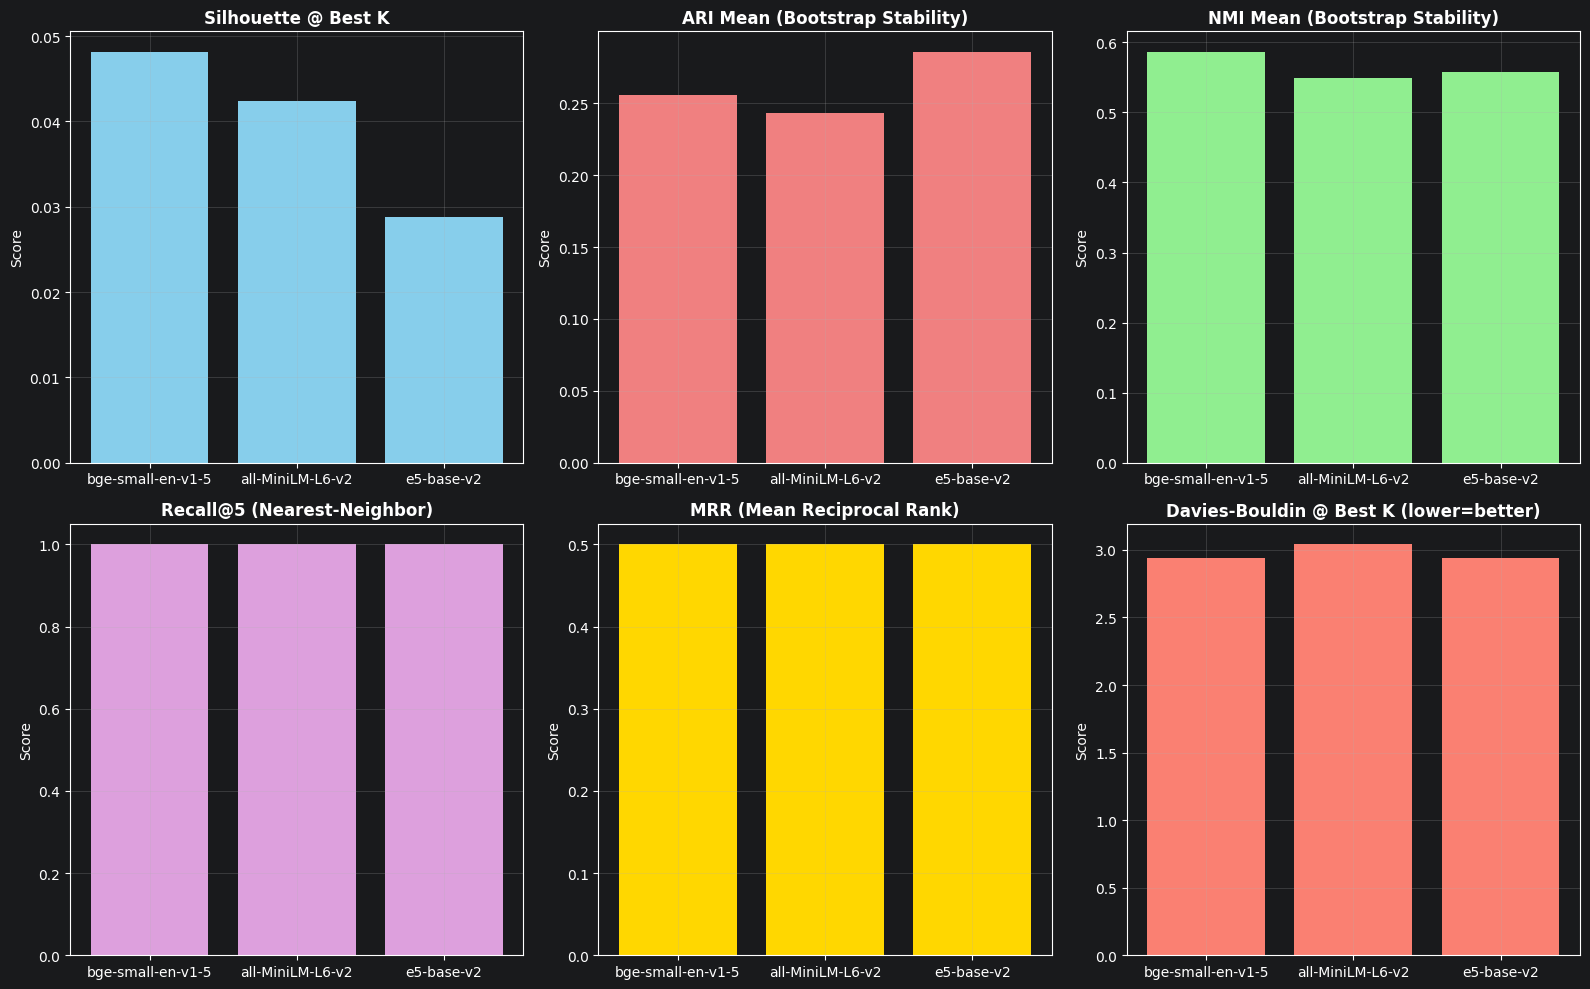

Figura salvata: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/embedding_model_comparison/model_comparison_metrics.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Silhouette per best K
axes[0, 0].bar(stability_df["model"], stability_df["silhouette_best_k"], color="skyblue")
axes[0, 0].set_title("Silhouette @ Best K", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Score")
axes[0, 0].grid(True, alpha=0.3)

# ARI Stability
axes[0, 1].bar(stability_df["model"], stability_df["ari_mean"], color="lightcoral")
axes[0, 1].set_title("ARI Mean (Bootstrap Stability)", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Score")
axes[0, 1].grid(True, alpha=0.3)

# NMI Stability
axes[0, 2].bar(stability_df["model"], stability_df["nmi_mean"], color="lightgreen")
axes[0, 2].set_title("NMI Mean (Bootstrap Stability)", fontsize=12, fontweight="bold")
axes[0, 2].set_ylabel("Score")
axes[0, 2].grid(True, alpha=0.3)

# Recall@5
axes[1, 0].bar(retrieval_df["model"], retrieval_df["recall@5"], color="plum")
axes[1, 0].set_title("Recall@5 (Nearest-Neighbor)", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Score")
axes[1, 0].grid(True, alpha=0.3)

# MRR
axes[1, 1].bar(retrieval_df["model"], retrieval_df["mrr"], color="gold")
axes[1, 1].set_title("MRR (Mean Reciprocal Rank)", fontsize=12, fontweight="bold")
axes[1, 1].set_ylabel("Score")
axes[1, 1].grid(True, alpha=0.3)

# Davies-Bouldin @ Best K (lower is better)
best_db = []
for model in stability_df["model"]:
    best_k = int(stability_df[stability_df["model"] == model]["best_k"].iloc[0])
    db_val = clustering_df[(clustering_df["model"] == model) & (clustering_df["k"] == best_k)]["davies_bouldin"].iloc[0]
    best_db.append(db_val)

axes[1, 2].bar(stability_df["model"], best_db, color="salmon")
axes[1, 2].set_title("Davies-Bouldin @ Best K (lower=better)", fontsize=12, fontweight="bold")
axes[1, 2].set_ylabel("Score")
axes[1, 2].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_PATH / "model_comparison_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salvata: {FIGURES_PATH / 'model_comparison_metrics.png'}")

## 6. Heatmap Metriche Aggregate

/tmp/ipykernel_229866/1553815726.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(heatmap_df.columns, rotation=45, ha="right")
/tmp/ipykernel_229866/1553815726.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(heatmap_df.index)


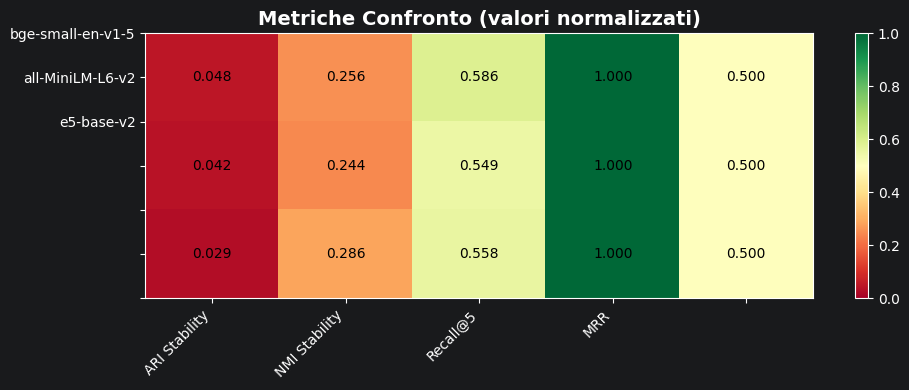

Figura salvata: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/embedding_model_comparison/model_comparison_heatmap.png


In [7]:
# Normalize metrics to [0, 1] for heatmap
heatmap_data = []

for _, row in stability_df.iterrows():
    model = row["model"]
    heatmap_data.append({
        "Model": model,
        "Silhouette": row["silhouette_best_k"],
        "ARI Stability": row["ari_mean"],
        "NMI Stability": row["nmi_mean"],
        "Recall@5": retrieval_df[retrieval_df["model"] == model]["recall@5"].iloc[0],
        "MRR": retrieval_df[retrieval_df["model"] == model]["mrr"].iloc[0],
    })

heatmap_df = pd.DataFrame(heatmap_data).set_index("Model")

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heatmap_df.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticklabels(heatmap_df.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_df.index)

# Add values in cells
for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        text = ax.text(j, i, f"{heatmap_df.values[i, j]:.3f}",
                      ha="center", va="center", color="black", fontsize=10)

ax.set_title("Metriche Confronto (valori normalizzati)", fontsize=14, fontweight="bold")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_PATH / "model_comparison_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salvata: {FIGURES_PATH / 'model_comparison_heatmap.png'}")

## 7. Visualizzazione 2D (PCA)

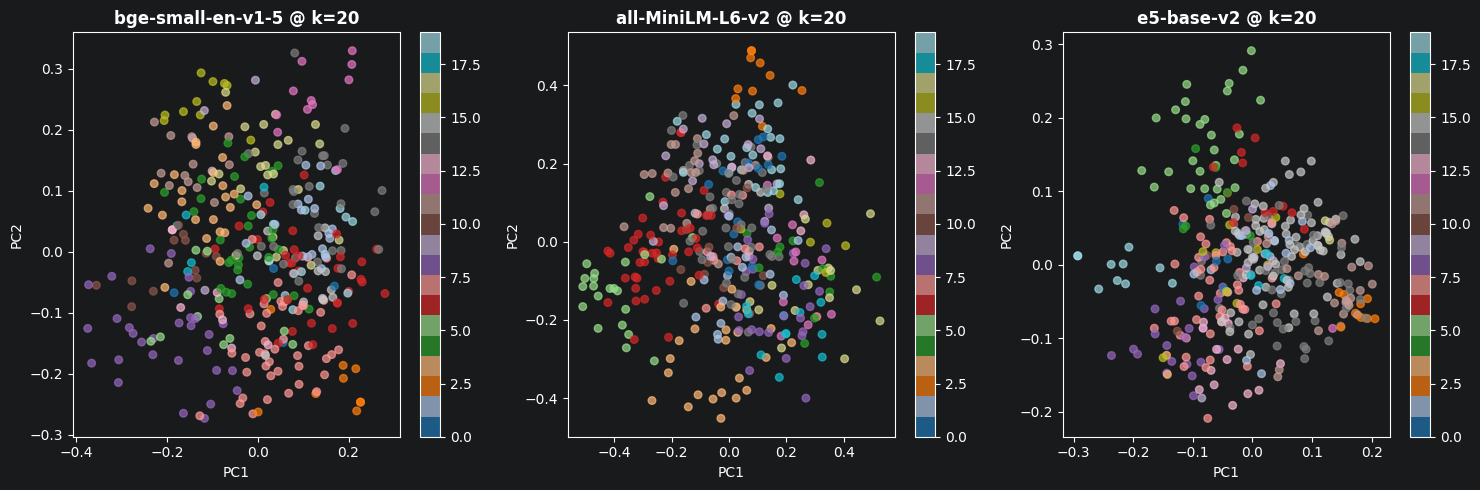

Figura salvata: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/embedding_model_comparison/model_comparison_pca_clusters.png


In [8]:
fig, axes = plt.subplots(1, len(embeddings_data), figsize=(5*len(embeddings_data), 5))

if len(embeddings_data) == 1:
    axes = [axes]

for idx, (model_name, data) in enumerate(embeddings_data.items()):
    slug = get_model_slug(model_name)
    embeddings = data["embeddings"]
    
    # Find best K
    best_k_row = stability_df[stability_df["model"] == slug].iloc[0]
    best_k = int(best_k_row["best_k"])
    
    # Cluster
    labels, _ = cluster_kmeans(embeddings, n_clusters=best_k)
    
    # Reduce to 2D
    embeddings_2d = reduce_embeddings(embeddings, method="pca", n_components=2)
    
    # Plot
    scatter = axes[idx].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap="tab20", s=30, alpha=0.7)
    axes[idx].set_title(f"{slug} @ k={best_k}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("PC1")
    axes[idx].set_ylabel("PC2")
    fig.colorbar(scatter, ax=axes[idx])

fig.tight_layout()
fig.savefig(FIGURES_PATH / "model_comparison_pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salvata: {FIGURES_PATH / 'model_comparison_pca_clusters.png'}")

## 8. Riassunto e Conclusioni

In [9]:
print("="*80)
print("CONFRONTO FINALE MODELLI EMBEDDING")
print("="*80)

print("\n### CLUSTERING QUALITY @ BEST K ###")
print(stability_df[["model", "best_k", "silhouette_best_k"]].to_string(index=False))

print("\n### STABILITY (Bootstrap) ###")
print(stability_df[["model", "ari_mean", "nmi_mean"]].to_string(index=False))

print("\n### RETRIEVAL METRICS ###")
print(retrieval_df[["model", "recall@5", "mrr"]].to_string(index=False))

print("\n" + "="*80)
print("IMMAGINI GENERATE:")
for f in FIGURES_PATH.glob("*.png"):
    print(f"  - {f.name}")

print("\n" + "="*80)
print("RACCOMANDAZIONI:")
print("="*80)

best_silhouette_model = stability_df.loc[stability_df["silhouette_best_k"].idxmax()]
best_stability_model = stability_df.loc[stability_df["ari_mean"].idxmax()]
best_retrieval_model = retrieval_df.loc[retrieval_df["recall@5"].idxmax()]

print(f"\n✓ Miglior Silhouette: {best_silhouette_model['model']} ({best_silhouette_model['silhouette_best_k']:.4f})")
print(f"✓ Miglior Stabilità (ARI): {best_stability_model['model']} ({best_stability_model['ari_mean']:.4f})")
print(f"✓ Miglior Retrieval (Recall@5): {best_retrieval_model['model']} ({best_retrieval_model['recall@5']:.4f})")

print("\nNota: Nessun modello è automaticamente scelto come vincitore.")
print("La scelta finale dipende dal use case e dalle priorità (velocità vs qualità).")

CONFRONTO FINALE MODELLI EMBEDDING

### CLUSTERING QUALITY @ BEST K ###
            model  best_k  silhouette_best_k
bge-small-en-v1-5      20           0.048155
 all-MiniLM-L6-v2      20           0.042365
       e5-base-v2      20           0.028799

### STABILITY (Bootstrap) ###
            model  ari_mean  nmi_mean
bge-small-en-v1-5  0.255616  0.586358
 all-MiniLM-L6-v2  0.243511  0.549166
       e5-base-v2  0.285706  0.558115

### RETRIEVAL METRICS ###
            model  recall@5  mrr
bge-small-en-v1-5       1.0  0.5
 all-MiniLM-L6-v2       1.0  0.5
       e5-base-v2       1.0  0.5

IMMAGINI GENERATE:
  - model_comparison_metrics.png
  - embedding_model_comparison_summary.png
  - model_comparison_pca_clusters.png
  - model_comparison_heatmap.png
  - embedding_single_model_diagnostics.png

RACCOMANDAZIONI:

✓ Miglior Silhouette: bge-small-en-v1-5 (0.0482)
✓ Miglior Stabilità (ARI): e5-base-v2 (0.2857)
✓ Miglior Retrieval (Recall@5): bge-small-en-v1-5 (1.0000)

Nota: Nessun modello 